# **7장 LangGraph**

In [ ]:
!pip install arxiv

In [ ]:
!pip install wikipedia

In [ ]:
gTTS는 명령프롬프트에서 설치하세요: pip install gTTS

## **LangGraph 전체 구조**

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# 1. State (상태): 노드들이 공유하는 데이터 정의
class State(TypedDict):
    message: str

# 2. Nodes (노드): 각 단계에서 할 일을 함수로 정의
def step_1(state: State):
    print("--- [1단계] 'Hello'를 추가합니다 ---")
    return {"message": state['message'] + "Hello"}

def step_2(state: State):
    print("--- [2단계] ', LangGraph!'를 추가합니다 ---")
    return {"message": state['message'] + ", LangGraph!"}

# 3. Graph (그래프): 전체 노드와 엣지를 묶는 역할
workflow = StateGraph(State)

# 4. 노드 등록 : 노드를 그래프에 등록
workflow.add_node("step_1", step_1)
workflow.add_node("step_2", step_2)

# 5. 엣지 연결 : 실행 순서 정하기
# Start -> step_1
workflow.add_edge(START, "step_1")

# step_1 -> step_2 (무조건 이동)
workflow.add_edge("step_1", "step_2")

# step_2 -> End (무조건 종료)
workflow.add_edge("step_2", END)

# 6. 컴파일 및 실행
app = workflow.compile()

inputs = {"message": ""}
result = app.invoke(inputs)

print(f"\n최종 결과: {result['message']}")


--- [1단계] 'Hello'를 추가합니다 ---
--- [2단계] ', LangGraph!'를 추가합니다 ---

최종 결과: Hello, LangGraph!


## **상태(State)**

In [4]:
# 기본 상태 구조
from typing_extensions import TypedDict
from typing import Annotated, List
from operator import add

class State(TypedDict):
    # overwrite 방식 
    current_step: str
    user_id: str

    # append 방식
    messages: Annotated[List[str], add]
    processing_log: Annotated[List[str], add]


In [7]:
# overwrite 방식 예제
from typing_extensions import TypedDict

class ExecutionState(TypedDict):
    step_index: int        # 기본 리듀서: 새 값으로 교체
    owner_id: str          # 기본 리듀서: 새 값으로 교체
    phase: str              # 기본 리듀서: 새 값으로 교체

def advance_step(state: ExecutionState) -> ExecutionState:
    """
    현재 실행 단계(step_index)만 증가시키는 노드.
    반환하지 않은 필드는 기존 상태를 그대로 유지한다.
    """
    return {
        "step_index": state["step_index"] + 1
    }

def finalize_phase(state: ExecutionState) -> ExecutionState:
    """
    실행이 종료될 때 호출되는 노드.
    여러 상태 값을 한 번에 갱신할 수 있다.
    """
    return {
        "step_index": 0,        # 단계 초기화
        "phase": "done"         # 실행 상태 변경
        # owner_id는 반환하지 않았으므로 변경되지 않음
    }


In [10]:
# append 방식 예제
from operator import add
from typing import Annotated

class AddState(TypedDict):
    # Annotated[타입, 리듀서함수] 형식으로 리듀서 지정
    messages: Annotated[list[str], add]      # 리스트에 추가
    log_text: Annotated[str, add]            # 문자열 연결

def add_message(state: AddState) -> AddState:
    """
    add 리듀서의 동작:
    - 리스트: 기존_리스트 + 새_리스트
    - 문자열: 기존_문자열 + 새_문자열
    """
    return {
        "messages": ["새 메시지"],              
        # 결과: state["messages"] + ["새 메시지"]

        "log_text": "새 로그 항목\n"            
        # 결과: state["log_text"] + "새 로그 항목\n"
    }

# 실행 예시
initial_state = {
    "messages": ["안녕하세요"],
    "log_text": "시작\n"
}

# add_message 노드 실행 후:
# {
#     "messages": ["안녕하세요", "새 메시지"],
#     "log_text": "시작\n새 로그 항목\n"
# }


# 메시지 전용 리듀서
# class ChatState(TypedDict): messages: Annotated[list, add_messages]


## **노드(Node)**

In [ ]:
# 사례 1 : LLM이 없는 노드 / 실행 안되는 사례
def increment(state):			# increment라는 함수를 정의, state라는 매개변수를 입력으로 받음 
    return {"counter": state["counter"] + 1}	# state의 counter 값을 1 증가시킨 새로운 상태를 반환
graph.add_node("increment", increment)	# add_node 메서드를 사용하여 정의한 함수를 그래프의 노드로 추가


In [ ]:
# 사례 2 : LLM을 사용하는 노드 / 실행 안되는 사례
llm = ChatOpenAI(model="gpt-4o-mini")
def call_llm(state: State) -> State:		# LLM을 호출하는 LangGraph 노드 함수 정의
    prompt = (                                     	# LLM에 전달할 프롬프트 생성
        f"질문: {state['cleaned_input']}\n"     	# 전처리된 사용자 입력을 질문으로 포함
        "답변을 한국어로 간단히:"               	# 응답 형식 지시
    )
    resp = llm.invoke(prompt)              	# LLM 호출 및 응답 객체 수신
    return {
        **state,     		                # 기존 State 유지
        "llm_answer": resp.content,   	# LLM 응답 텍스트를 State에 저장
    }


## **그래프(Graph), 노드 등록, 엣지 연결**

In [ ]:
# Graph (그래프): 전체 워크플로우 생성  / 실행 안됨
workflow = StateGraph(State)              # State를 공유하는 그래프 생성

# 노드 등록
workflow.add_node("step_1", step1)       # step1 함수를 “step_1” 노드로 등록
workflow.add_node("step_2", step2)       # step2 함수를 “step_2” 노드로 등록

# 엣지 연결 (실행 흐름 정의)
workflow.add_edge(START, "step_1")        # 시작 → step_1

workflow.add_edge("step_1", "step_2")     # step_1 실행 후 step_2로 이동

workflow.add_edge("step_2", END)          # step_2 실행 후 종료

# 컴파일
app = workflow.compile()                  # 그래프를 실행 가능한 앱으로 변환


## **Conditional edge**

In [ ]:
# 실행 안되는 코드
workflow = StateGraph(State)
# 노드 등록
workflow.add_node("decide", decide_node)
workflow.add_node("search", search_node)
workflow.add_node("answer", answer_node)

# 시작점
workflow.add_edge(START, "decide")

# 콘디셔널 엣지 등록
workflow.add_conditional_edges(
    "decide",      # 분기 기준 노드
     route,         # 상태를 보고 다음 노드 이름 반환
    {
        "search": "search",
        "answer": "answer",
    }
)
# 각 노드 종료 처리
workflow.add_edge("search", END)
workflow.add_edge("answer", END)


## **tool 사용**

In [ ]:
# 실행 안되는 코드
search_tool = DuckDuckGoSearchRun()	# DuckDuckGo 검색 도구 인스턴스 생성


def search_node(state: State) -> State:	# 검색을 수행하는 LangGraph 노드
    result = search_tool.run(   		# 질문을 DuckDuckGo로 검색
        state["question"]
    )
    return {
        **state,         			# 기존 State 유지
        "search_result": result      		# 검색 결과를 State에 저장
    }


## **코딩 : ① 도구 활용 Agent**

In [20]:
# 1. 모듈 불러오기 (Imports)
from typing import TypedDict, Optional 		 # LangGraph State 구조를 타입으로 명확히 정의
from langgraph.graph import StateGraph, START, END 	 # 상태 기반 그래프와 시작/종료 노드
from langchain_openai import ChatOpenAI  		 # OpenAI LLM을 LangChain 인터페이스로 사용
from langchain_community.tools import DuckDuckGoSearchRun 		# 웹/뉴스 검색 도구
from langchain_community.tools.wikipedia.tool import WikipediaQueryRun 	# 위키피디아 검색 도구
from langchain_community.utilities.wikipedia import WikipediaAPIWrapper 	# 위키피디아 API 래퍼
from langchain_community.tools.arxiv.tool import ArxivQueryRun  		# arXiv 논문 검색 도구

# 2. State 정의
class State(TypedDict):  # LangGraph에서 노드 간에 전달되는 상태(State)의 스키마
    question: str  # 사용자가 입력한 질문
    search_tool: Optional[str]  # 선택된 검색 도구 ("ddg" | "wiki" | "arxiv"), 아직 미정이면 None
    search_result: Optional[str]  # 검색 도구 실행 결과
    answer: Optional[str]  # 최종 LLM 답변


In [21]:
# 3. LLM 및 검색 도구 초기화
llm = ChatOpenAI(model="gpt-4o-mini")			# 판단(decide)과 답변(answer)에 사용될 LLM

ddg = DuckDuckGoSearchRun()  				# 최신 이슈, 뉴스, 일반 웹 검색용
wiki = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())  	# 개념, 정의, 인물 검색용
arxiv = ArxivQueryRun()  				# 논문, 연구 자료 검색용

SEARCH_TOOLS = { 					 # 문자열 키와 실제 검색 도구 객체를 연결
    "ddg": ddg,
    "wiki": wiki,
    "arxiv": arxiv,
}


In [22]:
# 4. 검색 도구 선택 노드 (Decide Node)
def decide_search_tool(state: State) -> State:  		# 질문을 보고 어떤 검색 도구를 쓸지 LLM이 판단
    prompt = f"""  				# 검색 도구 이름만 답하도록 제한한 프롬프트
질문을 보고 검색 도구를 하나만 고르세요.

- "arxiv": 논문/연구(ML, AI, science, paper, arXiv 등)
- "wiki": 개념/인물/역사/정의(백과사전 성격)
- "ddg": 최신 이슈/뉴스/웹 검색(시사성)

질문: {state["question"]}

아래 중 하나로만 답하세요: ddg | wiki | arxiv
"""
    tool = llm.invoke(prompt).content.strip().lower() 	 # LLM 호출 후 결과 문자열 정리
    if tool not in SEARCH_TOOLS:  			 # 허용되지 않은 값이 나올 경우 대비
        tool = "ddg"  # 기본값으로 DuckDuckGo 선택
    return {**state, "search_tool": tool}  # search_tool 값을 state에 저장

# 5. 라우터 함수 (Conditional Edge용)
def route(state: State) -> str:  # decide 노드 이후 이동할 노드를 결정
    return state["search_tool"] or "ddg"  # 값이 없으면 기본적으로 ddg 경로 사용


In [23]:
# 6. 검색 실행 노드 (Tool Node)
def run_search(state: State) -> State:  		# 선택된 검색 도구를 실제로 실행
    tool_name = state["search_tool"] or "ddg"  	# 사용할 검색 도구 이름 결정
    tool = SEARCH_TOOLS[tool_name]  		# 문자열 키를 Tool 객체로 변환
    result = tool.run(state["question"])  		# 질문을 기반으로 검색 수행
    return {**state, "search_result": result}  		# 검색 결과를 state에 저장


# 7. 답변 생성 노드 (Answer Node)
def answer(state: State) -> State:  			# 검색 결과를 참고해 최종 답변 생성
    prompt = f"""  				# 검색 결과를 컨텍스트로 제공
아래 검색 결과를 참고해서 질문에 답하세요.

질문: {state["question"]}

검색 결과:
{state["search_result"]}
"""
    resp = llm.invoke(prompt)  # LLM 호출
    return {**state, "answer": resp.content}  		# 생성된 답변을 state에 저장


In [24]:
# 8. LangGraph 워크플로우 구성
workflow = StateGraph(State)  			# State 타입을 사용하는 그래프 생성

workflow.add_node("decide", decide_search_tool)  	# 검색 도구 선택 노드
workflow.add_node("ddg", run_search)  		# DuckDuckGo 검색 노드
workflow.add_node("wiki", run_search)  		# Wikipedia 검색 노드
workflow.add_node("arxiv", run_search)  		# arXiv 검색 노드
workflow.add_node("answer", answer)  		# 답변 생성 노드

workflow.add_edge(START, "decide")  		# 시작 지점 → decide 노드
workflow.add_conditional_edges(  			# decide 결과에 따라 분기
    "decide",
    route,
    {"ddg": "ddg", "wiki": "wiki", "arxiv": "arxiv"}
)

workflow.add_edge("ddg", "answer")  		# 검색 후 answer로 이동
workflow.add_edge("wiki", "answer")
workflow.add_edge("arxiv", "answer")
workflow.add_edge("answer", END)  		# answer 이후 종료


In [26]:
# 9. 그래프 실행
app = workflow.compile()  		# 그래프를 실행 가능한 형태로 컴파일

out = app.invoke({  			# 초기 State 입력
    "question": "CNN 최신논문 추천해줘!",
    "search_tool": None,
    "search_result": None,
    "answer": None,
})

print(out["search_tool"])  		# 선택된 검색 도구 출력
print(out["answer"])  			# 최종 답변 출력


arxiv
최근 발표된 CNN 관련 논문 중 하나로, "Simultaneous Estimation of Elliptic Flow Coefficient and Impact Parameter in Heavy-Ion Collisions using CNN"를 추천합니다. 이 논문은 중이온 충돌에서 타원 흐름 계수와 충격 매개변수를 동시에 추정하는 CNN 기반의 방법을 제안합니다. 저자들은 Pb-Pb 충돌 데이터를 사용하여 CNN 모델을 훈련시키고, 모델의 성능을 평가하며, 실험 데이터와 비교하여 정확성을 입증했습니다. 이는 중이온 시스템에서 두 가지를 동시에 예측하는 첫 번째 시도입니다. 

이 외에도 CNN의 시각화와 이해를 돕는 도구에 관한 논문들도 흥미롭습니다. "CNN Explainer: Learning Convolutional Neural Networks with Interactive Visualization"은 비전문가가 CNN을 이해하고 학습할 수 있도록 돕는 인터랙티브한 시각화 도구를 소개합니다. 이 도구는 CNN의 구조를 요약하고, 사용자가 CNN의 내부 작동을 이해하는 데 도움을 줍니다.

이처럼 다양한 분야에서 CNN이 활용되고 있으니, 관심 있는 주제에 맞춰 선택하시면 좋겠습니다!


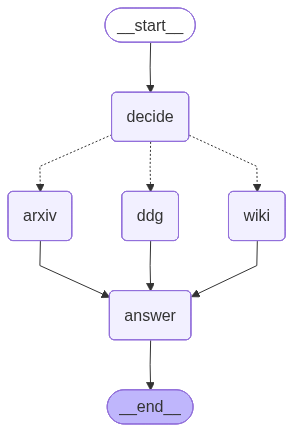

In [27]:
# 10. 그래프 그리기
from IPython.display import Image, display
png = app.get_graph().draw_mermaid_png()
display(Image(png))


## **코딩 : ② pdf 요약 Agent**

In [1]:
# 1. 모듈 불러오기
import os  		                               	 	# 경로/파일명 처리
from typing import TypedDict, Optional	 	# 상태 타입 정의용

from pypdf import PdfReader                       	# PDF 텍스트 추출
from docx import Document                        	# Word(.docx) 생성

from langchain_openai import ChatOpenAI      	# LLM 호출 래퍼
from langchain_core.messages import SystemMessage, HumanMessage  # 메시지 포맷

from langgraph.graph import StateGraph, END 	# LangGraph 구성 요소


# 2. LangGraph 상태(State) 정의
class State(TypedDict):                                          	 # 그래프가 공유할 상태
    pdf_path: str                                             	 # 입력 PDF 경로
    text: str                                                     	 # 추출된 텍스트
    summary: str                                                  	 # 요약 결과
    make_word: Optional[bool]                                      # 워드 저장 여부
    word_path: Optional[str]                                      	 # 생성된 워드 경로


In [2]:
# 3. PDF 텍스트 추출 함수
def pdf_to_text(pdf_path: str) -> str: 	
    reader = PdfReader(pdf_path)		# PDF 로드
    chunks = []                                           # 텍스트 누적
    total = 0                                               # 글자수 누적

    for page in reader.pages:                         # 페이지 순회
        t = page.extract_text() or ""                 # 페이지 텍스트
        if not t.strip():                                    # 빈 페이지 스킵
            continue

        chunks.append(t)                                # 페이지 텍스트 추가
        total += len(t)                                    # 누적 길이 업데이트

    return "\n".join(chunks)                           # 전체 텍스트 반환

# 4. 노드(Node) 함수들
# 4-1) PDF 로드 노드
def load_pdf_node(state: State) -> State:
    text = pdf_to_text(state["pdf_path"])           # PDF -> 텍스트
    return {**state, "text": text}                       # 상태 업데이트


In [3]:
# 4-2) 요약 노드
def summarize_node(state: State) -> State:
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)           # 모델/온도 설정

    system = SystemMessage(content=(                                       # 시스템 프롬프트
        "너는 요약 에이전트다.\n"
        "업로드된 PDF를 바탕으로 한국어로 요약하라.\n"
        "형식:\n"
        "1) 제목과 한줄 요약\n"
        "2) 개요 200 글자 \n"
        "3) 주요내용, 500글자씩 5개 단락 (불릿)\n"
        "4) 시사점, 300자 \n"
    ))
    user = HumanMessage(content=f"다음은 PDF에서 추출한 텍스트다:\n\n{state['text']}")  # 사용자 입력

    resp = llm.invoke([system, user])                                 # LLM 호출
    return {**state, "summary": resp.content}                      # 요약 저장


In [4]:
# 4-3) 조건 분기(라우팅) 함수
def route_after_ask(state: State) -> str:
    return "make_word" if state.get("make_word") else "end"        # yes면 워드 생성, 아니면 종료


# 4-4) 요약 출력 + Word 저장 여부 질문 노드
def ask_word_node(state: State) -> State:
    print("\n" + "="*80)                                          # 구분선
    print("📌 요약 결과")                                          # 타이틀
    print("="*80)                                                    # 구분선
    print(state["summary"])                                      # 요약 출력
    print("="*80)                                                    # 구분선

    ans = input("요약을 워드(.docx)로 저장할까요? (yes/no): ").strip().lower()  # 입력 받기
    make_word = (ans == "yes")                                                           # yes면 True
    return {**state, "make_word": make_word}                                         # 상태 업데이트


In [5]:
# 4-5) Word 파일 생성 노드
def make_word_node(state: State) -> State:
    out_path = os.path.splitext(state["pdf_path"])[0] + "_summary.docx"  # 출력 파일명

    doc = Document()                                            	     # 문서 생성
    doc.add_heading("PDF 요약 결과", level=1)                      # 제목 추가

    for line in state["summary"].splitlines():                          # 줄 단위 처리
        line = line.rstrip()                                                   # 오른쪽 공백 제거
        if not line:                                                             # 빈 줄이면
            doc.add_paragraph("")                                        # 빈 문단 추가
            continue

        if line.lstrip().startswith(("-", "•", "*")):                       # 불릿처럼 보이면
            doc.add_paragraph(line.lstrip("-•* ").strip(), style="List Bullet")  # 불릿 스타일
        else:
            doc.add_paragraph(line)                                     # 일반 문단

    doc.save(out_path)                                                    # 파일 저장
    print(f"Word 파일 저장 완료: {out_path}")                      # 저장 완료 안내
    return {**state, "word_path": out_path}                        # 워드 경로 저장


In [6]:
# 5. 그래프 구성(노드 연결)
graph = StateGraph(State)                                               # 그래프 생성(상태 타입 지정)
   
graph.add_node("load_pdf", load_pdf_node)                        # 노드 등록
graph.add_node("summarize", summarize_node)                  # 노드 등록
graph.add_node("ask_word", ask_word_node)                      # 노드 등록
graph.add_node("make_word", make_word_node)                 # 노드 등록

graph.set_entry_point("load_pdf")                                      # 시작 노드 지정

graph.add_edge("load_pdf", "summarize")                           # load -> summarize
graph.add_edge("summarize", "ask_word")                          # summarize -> ask_word

graph.add_conditional_edges(                                           # 조건 분기 연결
    "ask_word",                                                               # 분기 기준 노드
    route_after_ask,                                                          # 라우팅 함수
    {"make_word": "make_word", "end": END}                       # 분기 맵
)

graph.add_edge("make_word", END)                                  # make_word -> 종료
app = graph.compile()                                                    # 실행 가능한 앱으로 컴파일


In [7]:
# 6. 실행(주피터에서 경로만 바꿔 실행)

pdf_path = "../실습파일/steelweekly.pdf"                                 # PDF 경로 지정

result = app.invoke({                                              # 그래프 실행
    "pdf_path": pdf_path,                                         # 입력 경로
    "text": "",                                                         # 초기값
    "summary": "",                                                 # 초기값
    "make_word": None,                                          # 초기값
    "word_path": None,                                           # 초기값
})

# print(result.get("word_path"))                               # (선택) 생성 파일 경로 확인



📌 요약 결과
1) **제목과 한줄 요약**  
2025년 중국 철강 감산 가능성 높아져: 중국의 철강 생산 규제가 강화될 것으로 예상되며, 이는 원자재 가격과 글로벌 철강 시장에 영향을 미칠 전망이다.

2) **개요**  
2025년 중국의 철강 감산 가능성이 높아지고 있다. 중국 정부는 조강 생산 제한을 통해 산업 구조조정을 추진할 계획이며, 이는 원자재 수요에 영향을 미칠 것으로 보인다. 과거의 생산 규제 사례를 통해, 정부의 정책이 철강 생산량에 미치는 영향을 분석하고, 향후 시장 전망을 제시한다.

3) **주요내용**  
- **중국의 철강 생산 규제 역사**: 중국 정부는 2020년부터 철강 생산 규제를 도입하였으며, 2021년에는 엄격한 제한이 있었으나 이후에는 완화되었다. 2022년에는 의무적 규제가 없었음에도 불구하고 철강사들의 수익성 악화로 생산이 감소하였다.  
- **2025년 양회에서의 언급**: 2025년 양회 기간 동안 발개위(NDRC)는 조강 생산 통제가 생산 능력 감축과 산업 구조조정에 기여할 것이라고 언급하였다. 이는 공급 과잉이 심화될 경우 더욱 강력한 생산 규제가 시행될 수 있음을 시사한다.  
- **중국 내 철강 수요 감소**: 중국의 철강 수요가 감소하고 있으며, 이는 철강사들의 수익성 악화와 맞물려 있다. 특히 하반기로 갈수록 생산 감축이 더욱 두드러질 것으로 예상된다.  
- **원자재 가격에 미치는 영향**: 중국의 철강 생산 규제 강화로 인해 원자재 수요가 둔화될 것으로 보이며, 이는 철광석 가격 하락으로 이어질 가능성이 있다. 2월 말 기준으로 철광석 가격은 톤당 100달러로 하락하였다.  
- **글로벌 철강 시장에 미치는 영향**: 중국의 철강 감산은 글로벌 철강 시장에도 영향을 미칠 것으로 예상된다. 특히, 미국과 유럽의 철강 가격에 대한 압박이 증가할 수 있으며, 이는 수출입 구조에도 변화를 가져올 수 있다.  

4) **시사점**  
중국의 철강 감산 가능성은 글로벌 철강 시장에 중대한 영향을 

요약을 워드(.docx)로 저장할까요? (yes/no):  yes


Word 파일 저장 완료: ../실습파일/steelweekly_summary.docx


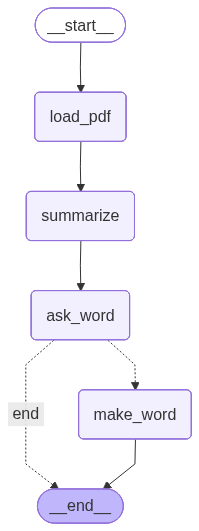

In [8]:
from IPython.display import Image, display
png = app.get_graph().draw_mermaid_png()
display(Image(png))
